# 01 · Trips Analysis After Circular Trips Removal

## Objective

1. Evaluate the impact of removing non-strict circular trips and outliers on the dataset to validate data quality and consistency.
2. Analyze route preferences based on Cyclist Profiles (Level of Traffic Stress) across various temporal, behavioral, and meteorological conditions, concluding with a geospatial visual comparison of the routing algorithms.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Data loading

Load the dataset containing the latest cleaning iteration, which excludes non-strict circular trips (trips that do not start and end at the same station) and removes outliers.

In [2]:
PATH_ORIGINAL = '../../data/processed/trips_final/'
PATH_AFTER_CLEANING = '../../data/processed/trips_final_cleaned/'

cols = ['member_casual', 'trip_duration', 'temperature_c', 'precipitation_mm', 'is_weekend', 'is_day', 'estimated_profile', 'estimation_error_sec', 'distance_m']

df_original = pd.read_parquet(PATH_ORIGINAL, columns=cols)
df_cleaned = pd.read_parquet(PATH_AFTER_CLEANING, columns=cols)

print(f'DataFrame shape before cleaning: {df_original.shape}')
print(f'DataFrame shape after cleaning: {df_cleaned.shape}')

DataFrame shape before cleaning: (40954601, 9)
DataFrame shape after cleaning: (38391306, 9)


Slightly over two million trips were removed following the latest data cleaning process. This is not a particularly large number considering the initial dataset contained over 40 million records. However, since most of these removed records share the characteristic of being long in duration but short in displacement distance, their removal might influence previously conducted analyses.

A preliminary comparison between the data before and after the cleaning process will be performed to observe any notable changes. Subsequently, the route analysis initiated in the previous notebook, `07_route_analysis.ipynb`, will be concluded.

## Data Comparison

Various charts will be presented to compare the differences between the datasets with and without these circular routes.

### Trip Duration

First, a chart displaying the volume of trips based on their actual duration will be presented.

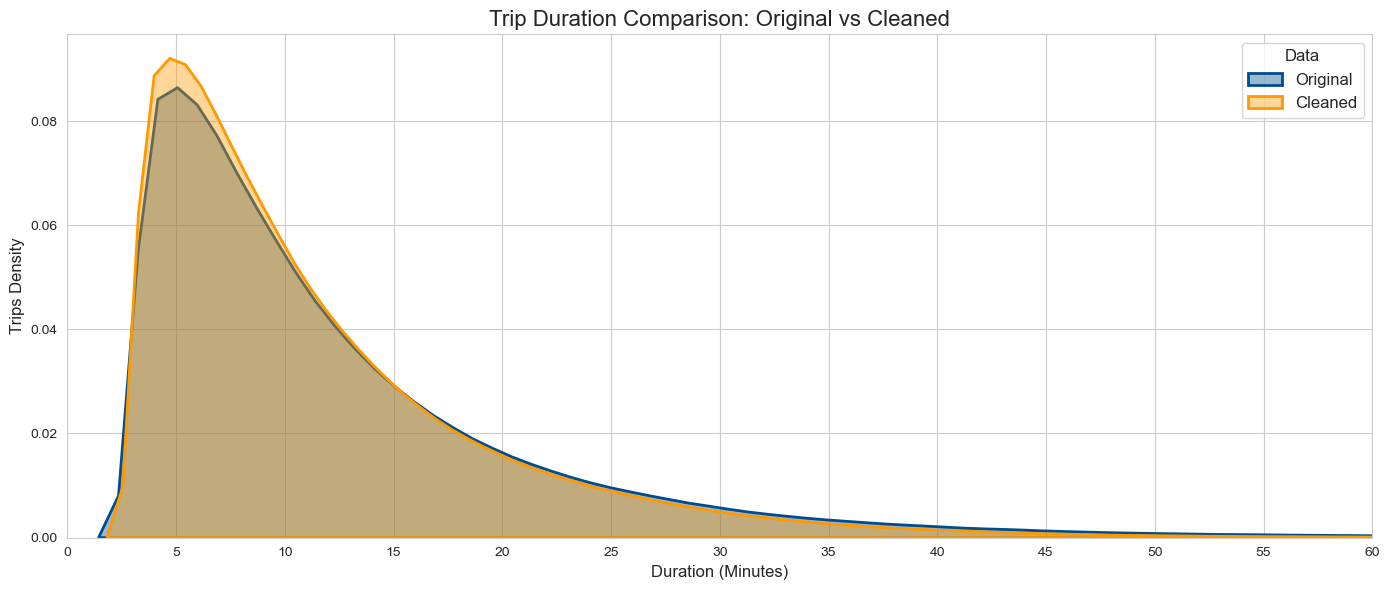

In [3]:
# Create auxiliary columns for trip duration in minutes
df_original['duration_min'] = df_original['trip_duration'] / 60
df_cleaned['duration_min'] = df_cleaned['trip_duration'] / 60

# Get samples for plotting because datasets are too large
SAMPLE_SIZE = 4000000 

if len(df_original) > SAMPLE_SIZE:
    plot_original = df_original.sample(n=SAMPLE_SIZE, random_state=42)
else:
    plot_original = df_original

if len(df_cleaned) > SAMPLE_SIZE:
    plot_cleaned = df_cleaned.sample(n=SAMPLE_SIZE, random_state=42)
else:
    plot_cleaned = df_cleaned

plt.figure(figsize=(14,6))
sns.set_style("whitegrid")

sns.kdeplot(
    data=plot_original,
    x='duration_min',
    color='#004c8c',
    alpha=0.4,
    label='Original',
    linewidth=2,
    fill=True
)

sns.kdeplot(
    data=plot_cleaned,
    x='duration_min',
    color='#ff9900',
    alpha=0.4,
    label='Cleaned',
    linewidth=2,
    fill=True
)

plt.title('Trip Duration Comparison: Original vs Cleaned', fontsize=16)
plt.xlabel('Duration (Minutes)', fontsize=12)
plt.ylabel('Trips Density', fontsize=12)

plt.xlim(0, 60)
plt.xticks(np.arange(0, 61, 5))

plt.legend(title='Data', fontsize=12, title_fontsize=12)
plt.tight_layout()
plt.show()

At first glance, the increased density of short trips (< 10 min) in the cleaned dataset might seem counterintuitive after having removed records. However, this result is a clear indicator of the data cleaning's quality.

It is important to note that a KDE (Kernel Density Estimate) plot does not represent absolute frequencies, but rather probability density. Since the area under the curve must always sum to 1 (100%), removing long duration outliers, primarily corresponding to circular trips, causes a renormalization of the distribution. By deleting data from the right-hand 'long tail', the probability mass is redistributed, proportionally increasing the density of shortduration trips, which accurately reflect true urban transport behavior.

### User Type Proportion: Members vs. Casuals

The proportion of trips made by members and casual users will be compared to verify whether the removal of circular trips has disproportionately affected casual usage.

In [4]:
def plot_distribution(df, column, ax, title, labels_map=None, palette=None):
    """
    Generic function to plot distribution of any categorical column.
    
    Parameters:
    - df: DataFrame with the data.
    - column: Name of the column to analyze.
    - ax: Matplotlib axis where to plot.
    - title: Title of the plot.
    - labels_map: Dictionary to rename values.
    - palette: List of colors.
    """
    
    # Prepate data
    counts = df[column].value_counts().reset_index()
    counts.columns = ['Category', 'Count']
    
    # If labels_map is provided, map the category names
    if labels_map:
        counts['Category'] = counts['Category'].map(labels_map)

    sns.barplot(
        data=counts, 
        x='Category', 
        y='Count', 
        hue='Category', 
        palette=palette, 
        ax=ax
    )
    
    ax.set_title(title, fontweight='bold', pad=20, fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("Total Trips")
    sns.despine(ax=ax, left=True)
    
    total = len(df)
    for p in ax.patches:
        height = p.get_height()
        if pd.isna(height): height = 0
            
        percentage = '{:.1f}%'.format(100 * height / total)
        
        ax.annotate(f'{int(height):,} ({percentage})', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=11, color='grey', weight='bold')

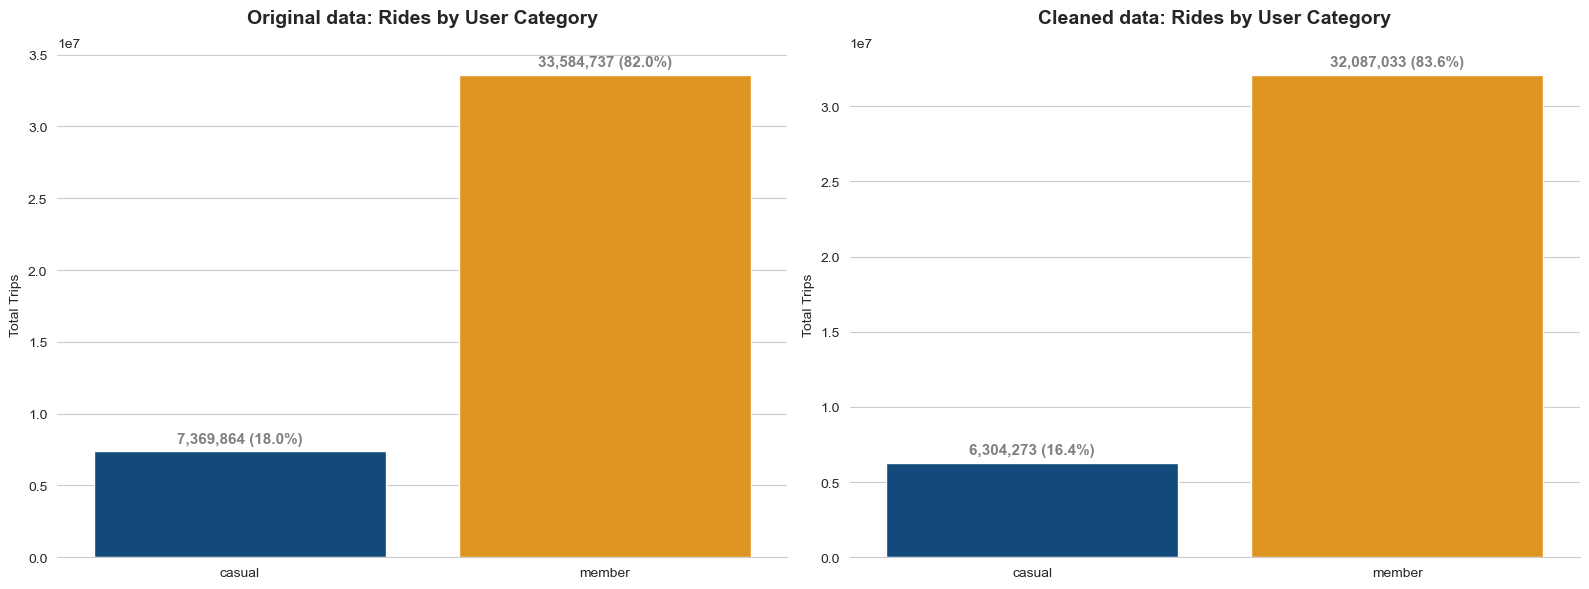

In [5]:
colors = ["#004c8c", "#ff9900"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_distribution(df_original, 'member_casual', axes[0], "Original data: Rides by User Category", palette=colors)
plot_distribution(df_cleaned, 'member_casual', axes[1], "Cleaned data: Rides by User Category", palette=colors)

plt.tight_layout()
plt.show()

Although the proportion has barely changed, a slight decrease in casual user trips and an increase in member trips can be observed. This reinforces the hypothesis that non-strict circular trips are primarily undertaken by casual users utilizing the bikesharing service for leisure, sightseeing, or recreational rides around the city.

### Weekday vs. Weekend Trip Proportion

Similar to the previous charts, this aims to verify whether the removed circular trips were predominantly leisure trips (typically occurring on weekends) or errands/commuting trips (typically occurring on weekdays).

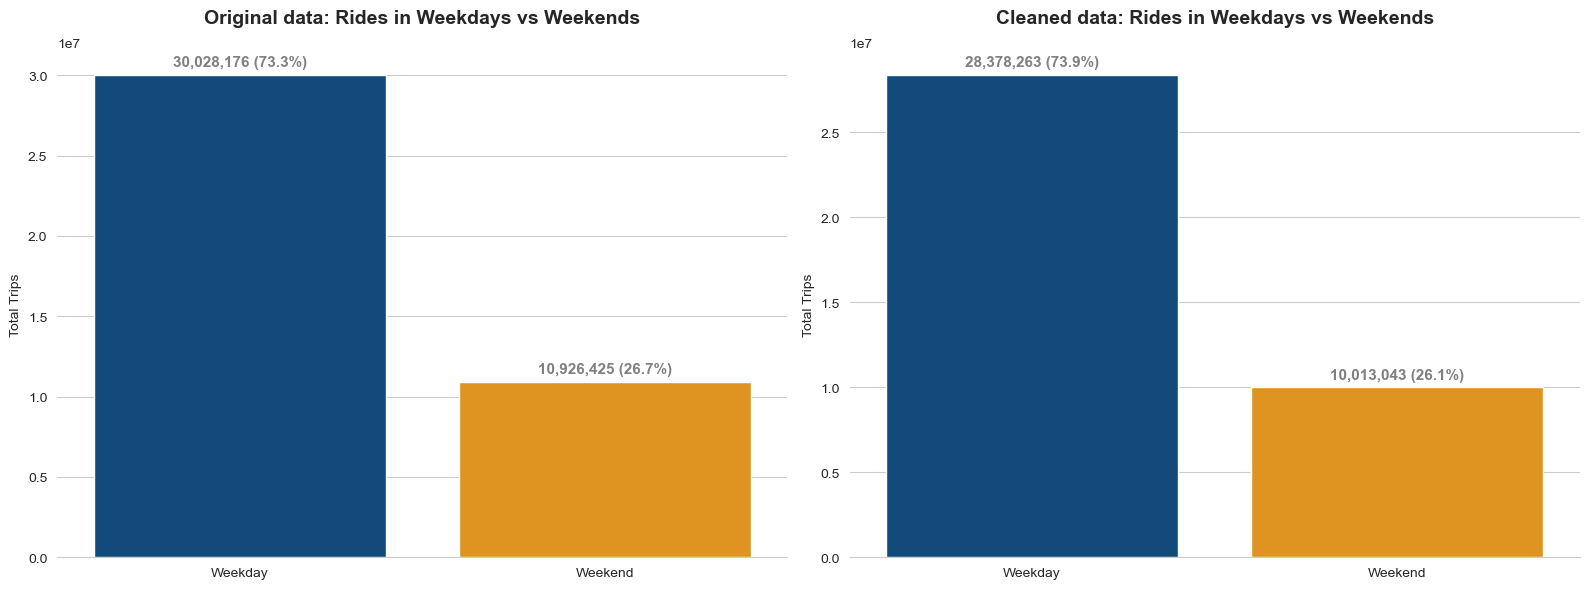

In [6]:
map_week = {0: 'Weekday', 1: 'Weekend'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_distribution(df_original, 'is_weekend', axes[0], "Original data: Rides in Weekdays vs Weekends", labels_map=map_week, palette=colors)
plot_distribution(df_cleaned, 'is_weekend', axes[1], "Cleaned data: Rides in Weekdays vs Weekends", labels_map=map_week, palette=colors)

plt.tight_layout()
plt.show()

The proportion of trips made during weekdays versus weekends has remained largely unchanged, indicating that these leisure trips are distributed quite evenly regardless of the day of the week.

### Mean Estimation Error by Trip Distance

Finally, an assessment will be made to determine if the issue of circular trips between nearby stations artificially inflating the mean estimation error and distorting the graph has been resolved.

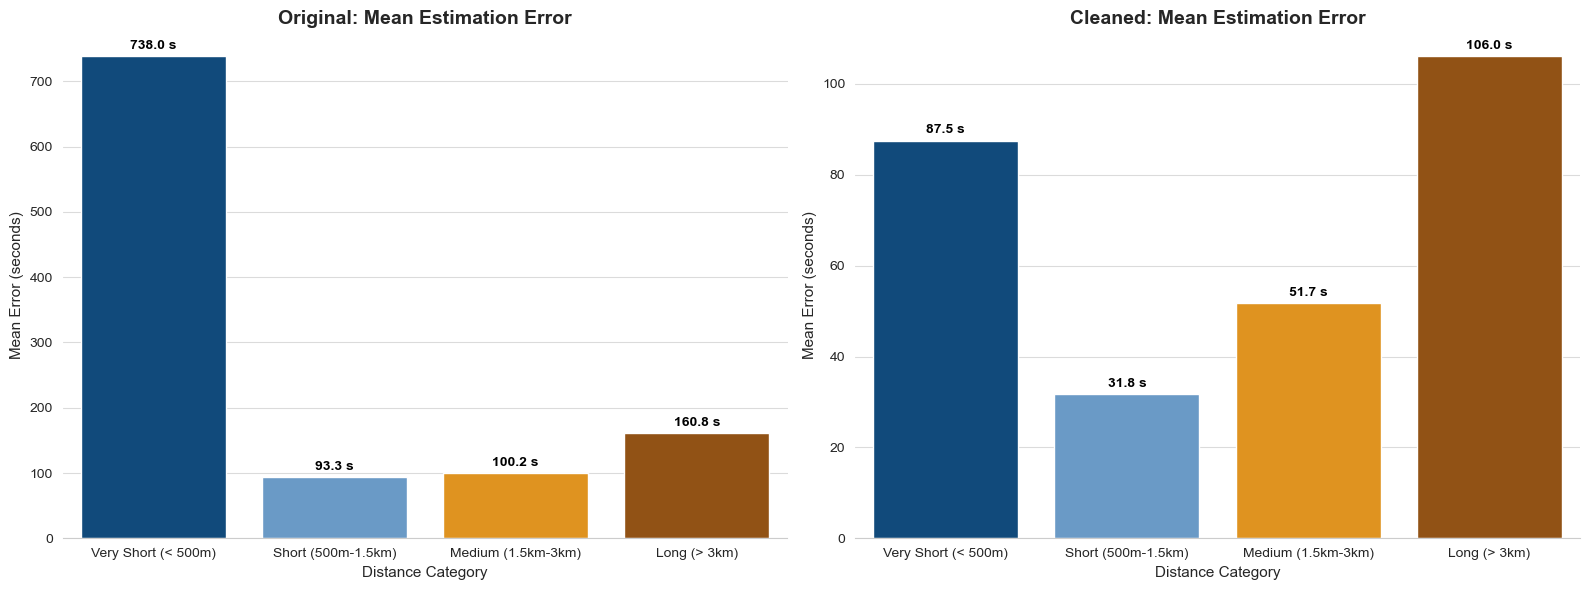

In [7]:
bins = [0, 500, 1500, 3000, float('inf')]
labels = ['Very Short (< 500m)', 'Short (500m-1.5km)', 'Medium (1.5km-3km)', 'Long (> 3km)']
custom_palette = ["#004c8c", "#5b9bd5", "#ff9900", "#a65200"]

def get_mean_errors(df):
    df_temp = df.copy()
    df_temp['dist_group_error'] = pd.cut(
        df_temp['distance_m'], 
        bins=bins, 
        labels=labels, 
        right=True
    )
    return (
        df_temp
        .groupby('dist_group_error', observed=True)['estimation_error_sec']
        .mean()
        .reset_index()
    )

mean_errors_orig = get_mean_errors(df_original)
mean_errors_clean = get_mean_errors(df_cleaned)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

sns.barplot(
    data=mean_errors_orig,
    x='dist_group_error',
    y='estimation_error_sec',
    hue='dist_group_error',
    palette=custom_palette,
    ax=axes[0]
)
axes[0].set_title('Original: Mean Estimation Error', fontsize=14, fontweight='bold')

sns.barplot(
    data=mean_errors_clean,
    x='dist_group_error',
    y='estimation_error_sec',
    hue='dist_group_error',
    palette=custom_palette,
    ax=axes[1]
)
axes[1].set_title('Cleaned: Mean Estimation Error', fontsize=14, fontweight='bold')

for ax in axes:
    ax.set_xlabel('Distance Category', fontsize=11)
    ax.set_ylabel('Mean Error (seconds)', fontsize=11)
    
    sns.despine(ax=ax, left=True)
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='-', alpha=0.7)
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f s', padding=3, fontsize=10, color='black', fontweight='bold')

plt.tight_layout()
plt.show()

While intuition suggests that the estimation error should increase linearly as trip distance grows, due to a higher probability of encountering traffic lights or route disruptions, the very short trip category (under 500 meters) presents an anomaly with a significantly elevated mean error. This phenomenon should not be interpreted as a data flaw, but rather as a reflection of the inelasticity of essential operational times inherent to the bikesharing system. The discrepancy is primarily explained by the significant weight of fixed temporal costs compared to actual travel time. Routing algorithms, such as GraphHopper, exclusively calculate pure movement time based on road speed limits. However, the actual user experience includes a setup phase (saddle adjustment or initial orientation) and a docking phase (involving deceleration, docking maneuvers, and waiting for system confirmation). In medium-distance trips, these processes represent a marginal percentage of the total time and are diluted in the statistics. Conversely, in a short displacement of merely three or four minutes, these constant and unavoidable fixed times can constitute half of the total trip duration, generating a massive deviation from the theoretical estimation.

Compounding this operational limitation is the physical impossibility of recovering time through speed over such short distances. In longer journeys, cyclists have sufficient margin to increase their cadence and make up for seconds lost during departure or at a slow intersection, bringing their total time closer to the algorithm's estimate. For trips under 500 meters, this recovery margin is non-existent, the brevity of the route prevents the user from establishing a cruising speed that compensates for initial delays, causing any departure lag to directly impact the final error.

Finally, it is crucial to consider the urban "last-mile" context where these micro-displacements typically occur. A large portion of these short trips serves an intermodal purpose, connecting public transit hubs with final destinations in highly dense pedestrian areas. In these environments, pedestrian friction forces users to drastically reduce their speed or even walk the bicycle during the first and last meters of the journey to navigate congestion or access the station. Since the routing engine assumes a standard clear-path speed and does not account for these micro-interruptions caused by pedestrian density, the estimation remains persistently optimistic compared to the reality of a saturated environment. Ultimately, the error observed in this category does not measure route uncertainty, but rather quantifies the physiological threshold of human and operational friction within the system.

Regardless, looking at the final data, it can be concluded that the data cleaning process was highly successful. Excluding the aforementioned operational constraints, errors across all other trip categories are remarkably low, reaching a maximum deviation of just over a minute and a half for trips exceeding 3 kilometers, which indicates a very high level of precision.

## Route Analysis

In this section, a route analysis will be conducted now that the circular route issue has been resolved. It will begin with a general study of certain trip characteristics and subsequently transition to an evaluation of system usage based on external variables such as weather and lighting conditions.

### Trip Usage Proportion by Route Profile

The following chart displays the proportion of trips categorized by the predefined routing profiles based on user preference: `Kids` for quiet rides strictly adhering to protected cycling infrastructure; `Safe` for users preferring protected infrastructure but willing to use shared cycling paths; `Confident` for higher speeds and faster roads if it significantly reduces travel time; and finally, `Direct` for users strictly focused on the shortest and fastest path to the destination, regardless of traffic conditions or cycling infrastructure.

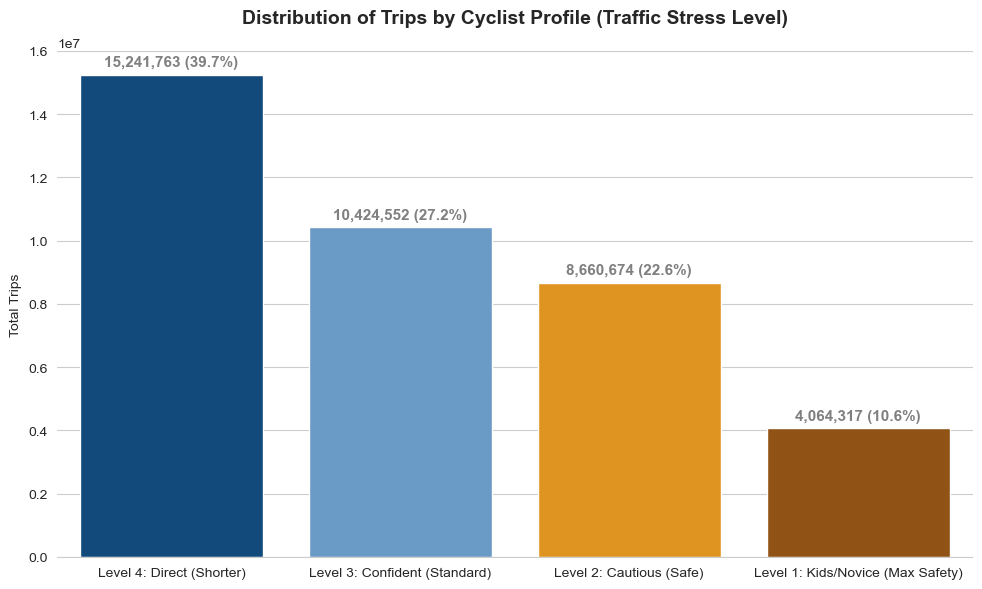

TRIP DISTRIBUTION BY PROFILE
                                      Count  Percentage
estimated_profile                                      
Level 4: Direct (Shorter)          15241763   39.701080
Level 3: Confident (Standard)      10424552   27.153419
Level 2: Cautious (Safe)            8660674   22.558946
Level 1: Kids/Novice (Max Safety)   4064317   10.586556


In [8]:
map_profiles = {
    'lts1_kids': 'Level 1: Kids/Novice (Max Safety)',
    'lts2_safe': 'Level 2: Cautious (Safe)',
    'lts3_confident': 'Level 3: Confident (Standard)',
    'lts4_direct': 'Level 4: Direct (Shorter)'
}

fig, ax = plt.subplots(figsize=(10, 6))
plot_distribution(
    df_cleaned, 
    'estimated_profile', 
    ax, 
    "Distribution of Trips by Cyclist Profile (Traffic Stress Level)", 
    labels_map=map_profiles, 
    palette=custom_palette
)

plt.tight_layout()
plt.show()

print("TRIP DISTRIBUTION BY PROFILE")
counts = df_cleaned['estimated_profile'].value_counts()
percs = df_cleaned['estimated_profile'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'Count': counts, 'Percentage': percs})
summary.index = summary.index.map(map_profiles)
print(summary)

The results reveal a clear hierarchy in route selection, dominated by the LTS4 'Direct / Shorter' profile, which accounts for 39.7% of the trips (approx. 15 million), followed by the LTS3 'Confident' profile at 27.15%. Conversely, the maximum safety profile (LTS1 'Kids/Novice') is residual, representing only 10.6% of the total.

This distribution validates the "utilitarian cyclist" hypothesis. Given that the vast majority of trips are undertaken by annual subscribers (Members) during weekdays, it can be inferred that the typical Citibike user prioritizes temporal efficiency over comfort or segregated safety. This behavior is consistent with urban cycling literature, where experienced commuters exhibit a higher tolerance for traffic stress in exchange for reduced travel times.

Additionally, the low prevalence of the LTS1 profile is explained by two structural factors:
1. Network Discontinuity: Maximum safety infrastructure (greenways, fully segregated lanes) often lacks the necessary connectivity for complete end-to-end journeys, forcing users to navigate lower-safety segments (LTS3 or LTS4) to complete their routes.
2. Speed-Based Assignment Bias: Methodologically, it is probable that a fraction of users utilize safe infrastructure (LTS1 routes) at high speeds. Since the assignment model is based on time matching, these fast trips on safe paths are mathematically classified under more aggressive profiles (LTS2 or LTS3) because their travel time is lower than the conservative estimate of the 'Kids' profile. Therefore, it is highly likely that the LTS4 profile captures both users taking direct, high-stress routes and users riding quickly on safe infrastructure.

### Route Profile Proportion by Time of Day (Day vs. Night)

The previous analysis will be replicated, segmenting trips by daytime and nighttime, to determine whether reduced nocturnal traffic influences a higher preference for direct routes over safer ones.

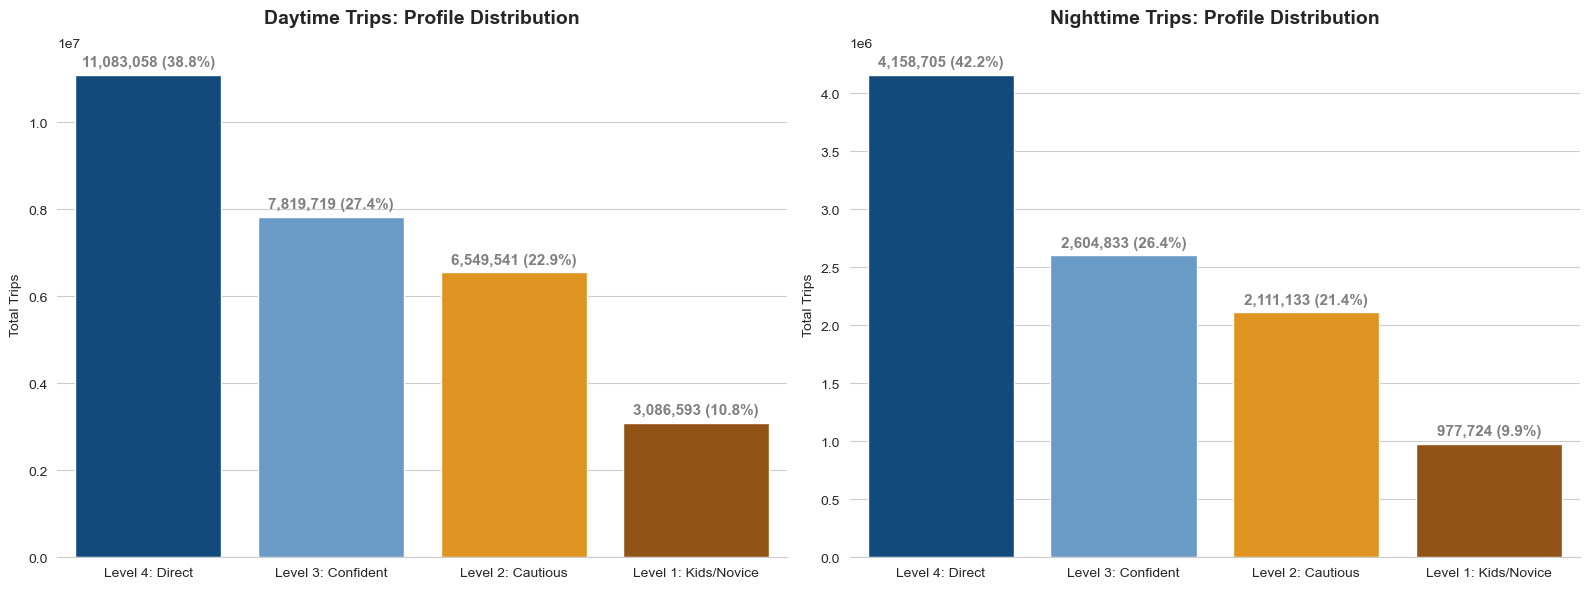

In [9]:
map_profiles = {
    'lts1_kids': 'Level 1: Kids/Novice',
    'lts2_safe': 'Level 2: Cautious',
    'lts3_confident': 'Level 3: Confident',
    'lts4_direct': 'Level 4: Direct'
}

df_day = df_cleaned[df_cleaned['is_day'] == 1]
df_night = df_cleaned[df_cleaned['is_day'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_distribution(
    df_day, 
    'estimated_profile', 
    axes[0], 
    "Daytime Trips: Profile Distribution", 
    labels_map=map_profiles, 
    palette=custom_palette
)

plot_distribution(
    df_night, 
    'estimated_profile', 
    axes[1], 
    "Nighttime Trips: Profile Distribution", 
    labels_map=map_profiles, 
    palette=custom_palette
)

plt.tight_layout()
plt.show()

The chart analysis reveals that the hierarchy of cyclist profile preferences remains structurally unchanged regardless of the time of day. However, although the usage order is identical during both daytime and nighttime, a slight percentage increase in the use of the direct route profile is observed at night, at the expense of more conservative options. This suggests a higher propensity among users to prioritize efficiency and speed, taking advantage of the predictable decrease in motorized traffic during those hours.

### Route Profile Proportion by Weekday vs. Weekend

This aims to verify if weekday trips—heavily driven by commuting to work or transit stations—favor more direct routes to save time, whereas weekend trips, lacking such urgency, prioritize safer routes.

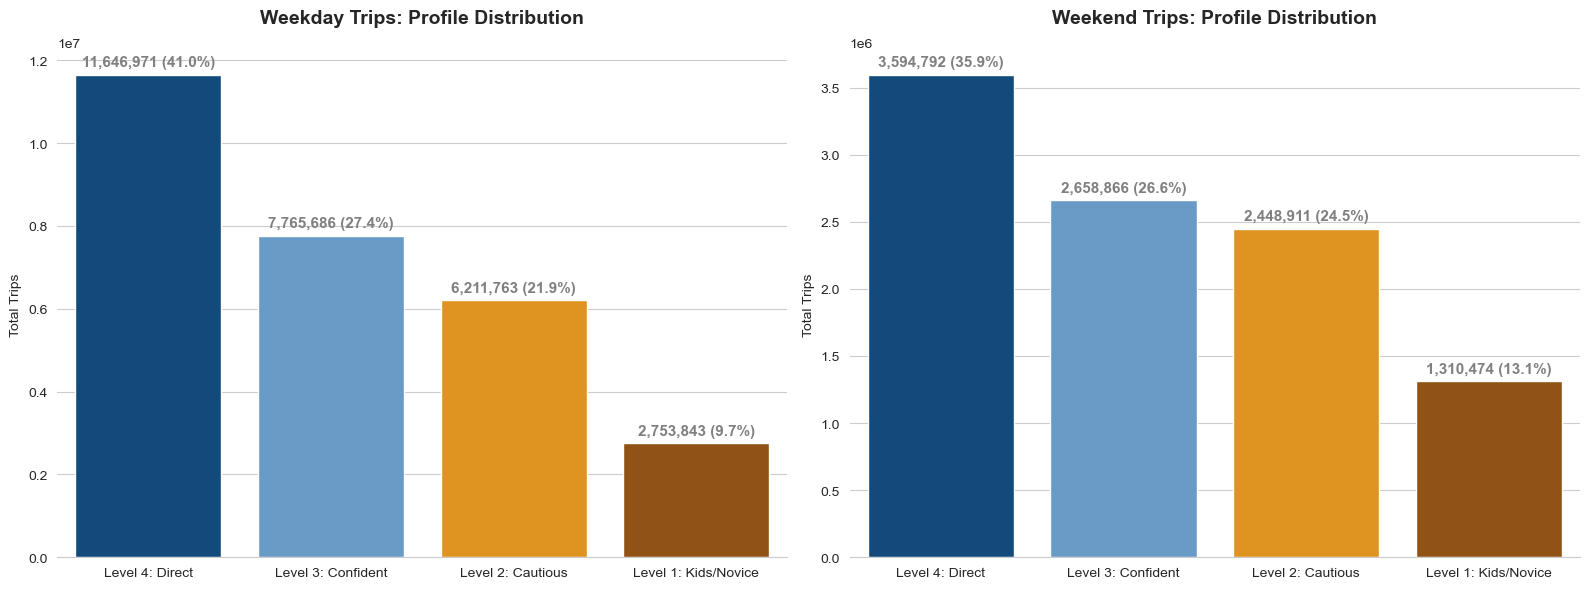

In [10]:
df_weekday = df_cleaned[df_cleaned['is_weekend'] == 0]
df_weekend = df_cleaned[df_cleaned['is_weekend'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_distribution(
    df_weekday, 
    'estimated_profile', 
    axes[0], 
    "Weekday Trips: Profile Distribution", 
    labels_map=map_profiles, 
    palette=custom_palette
)

plot_distribution(
    df_weekend, 
    'estimated_profile', 
    axes[1], 
    "Weekend Trips: Profile Distribution", 
    labels_map=map_profiles, 
    palette=custom_palette
)

plt.tight_layout()
plt.show()

The comparative analysis between weekdays and weekends reveals a significant modal divergence in user behavior. While over 40% of trips from Monday to Friday are concentrated in the fastest and most direct route profile, presumably driven by mandatory commuting and intermodal connections where time efficiency is paramount, this trend shifts over the weekend. On rest days, the preference for lower-stress infrastructure experiences a notable increase, causing the intermediate precaution level (LTS2 - Safe) to reach a usage share nearly identical to that of the advanced cyclist profile. This structural variation responds to a fundamental change in the nature of travel, evidencing a clear transition from a strictly utilitarian mobility model bound by time constraints to a much more recreational, balanced use of the service focused on journey comfort.

### Trip Volume and Route Proportion by Rainfall

The impact of rain on system usage will be evaluated, differentiating between light rain and heavy rain, to observe how this variable affects overall usage and the specific routes chosen by users.

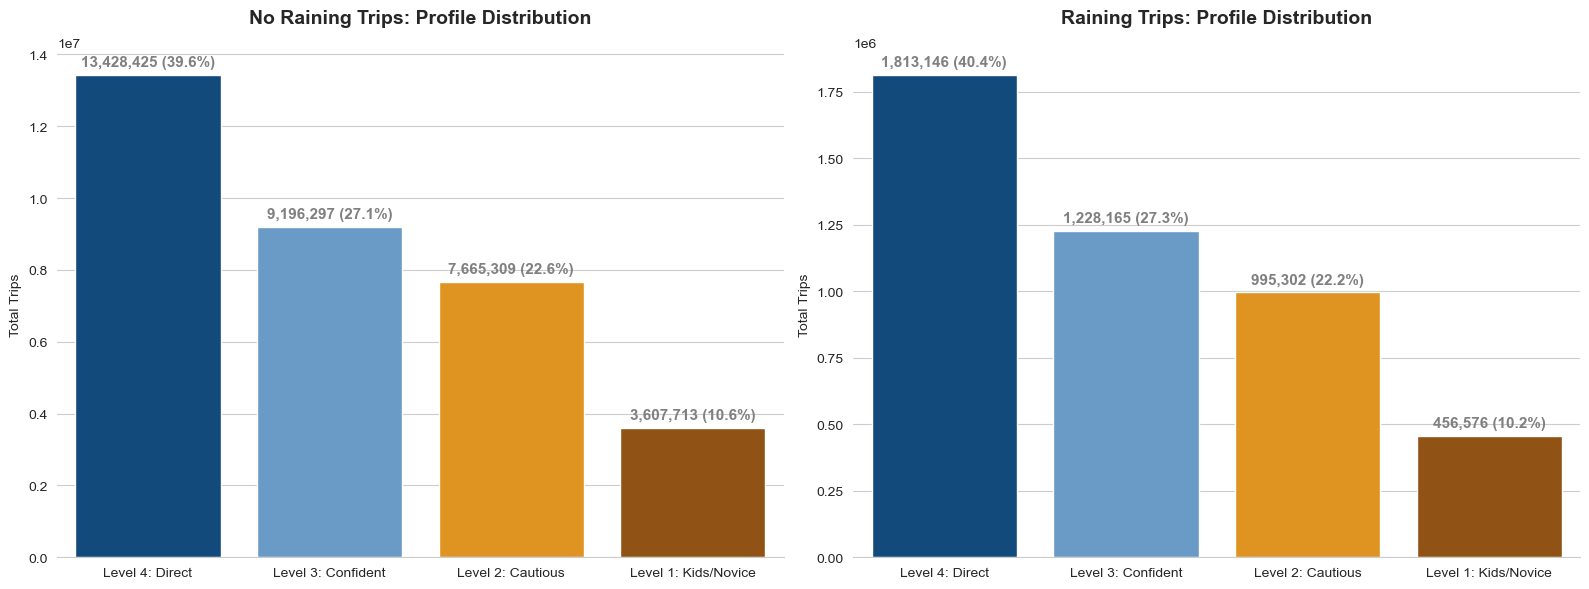

In [11]:
df_no_rain = df_cleaned[df_cleaned['precipitation_mm'] == 0.0]
df_rain = df_cleaned[df_cleaned['precipitation_mm'] > 0.0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_distribution(
    df_no_rain, 
    'estimated_profile', 
    axes[0], 
    "No Raining Trips: Profile Distribution", 
    labels_map=map_profiles, 
    palette=custom_palette
)

plot_distribution(
    df_rain, 
    'estimated_profile', 
    axes[1], 
    "Raining Trips: Profile Distribution", 
    labels_map=map_profiles, 
    palette=custom_palette
)

plt.tight_layout()
plt.show()

The initial analysis comparing non-precipitation scenarios against rainy days shows no significant differences in route profile selection. This structural homogeneity suggests that light precipitation (under 2 mm), being statistically more frequent, does not substantially alter user behavior or their traffic tolerance threshold. To isolate the true impact of adverse weather conditions, it is methodologically necessary to refine the experiment by segmenting precipitation into two intensity levels: light or moderate rain (up to 15 mm) and heavy rain (over 15 mm).

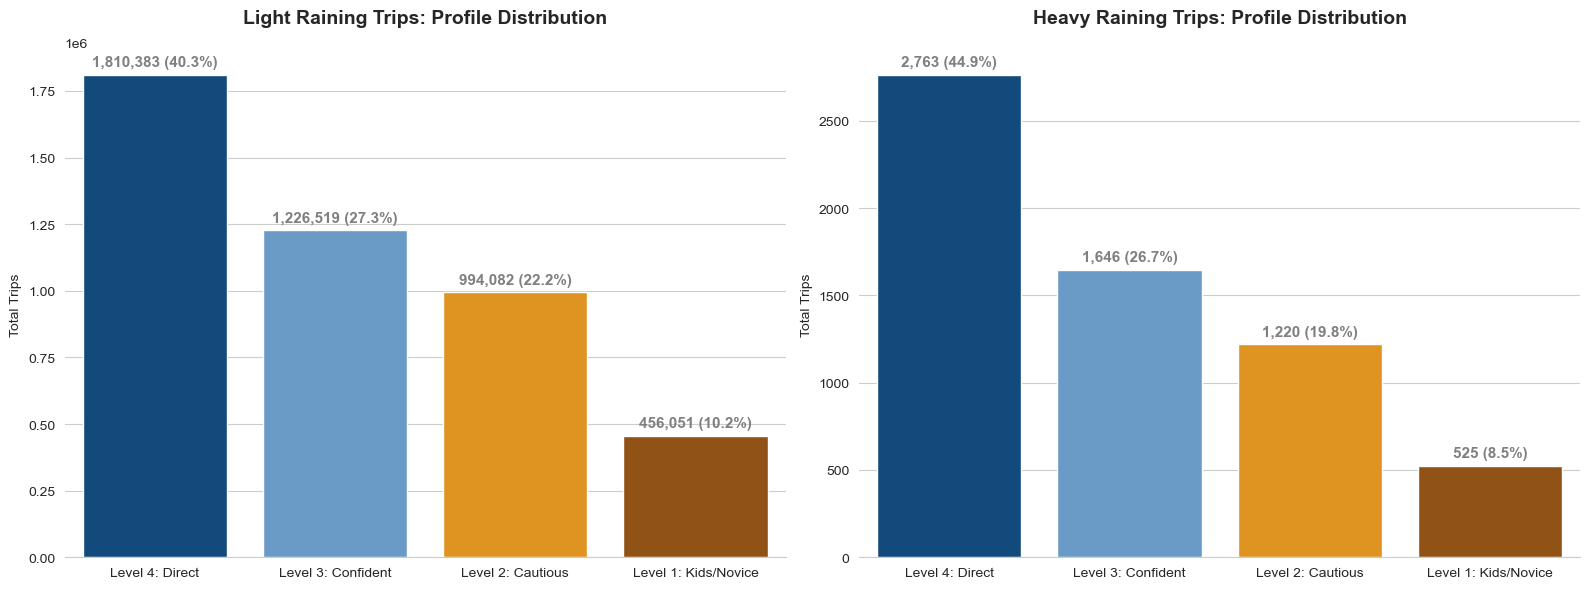

In [12]:
mask = (df_cleaned['precipitation_mm'] > 0.0) & (df_cleaned['precipitation_mm'] < 15.0)
df_light_rain = df_cleaned[mask]
df_heavy_rain = df_cleaned[df_cleaned['precipitation_mm'] >= 15.0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_distribution(
    df_light_rain, 
    'estimated_profile', 
    axes[0], 
    "Light Raining Trips: Profile Distribution", 
    labels_map=map_profiles, 
    palette=custom_palette
)

plot_distribution(
    df_heavy_rain, 
    'estimated_profile', 
    axes[1], 
    "Heavy Raining Trips: Profile Distribution", 
    labels_map=map_profiles, 
    palette=custom_palette
)

plt.tight_layout()
plt.show()

Applying this new categorization reveals evident modal divergences. During heavy rain episodes, the adoption of the direct route profile experiences a notable surge, rising from 40.3% to 44.9%. This trend shift empirically demonstrates that, under severe weather conditions, cyclists drastically reevaluate their travel priorities, favoring the minimization of exposure time to the elements and route speed over the use of lower-stress segregated infrastructure.

### Trip Volume and Route Proportion by Temperature

To complement the meteorological impact analysis, the influence of thermal stress on route selection was evaluated, contrasting user behavior under extreme temperatures (severe cold, below 5 ºC, and intense heat, above 30 ºC) against moderate thermal ranges.

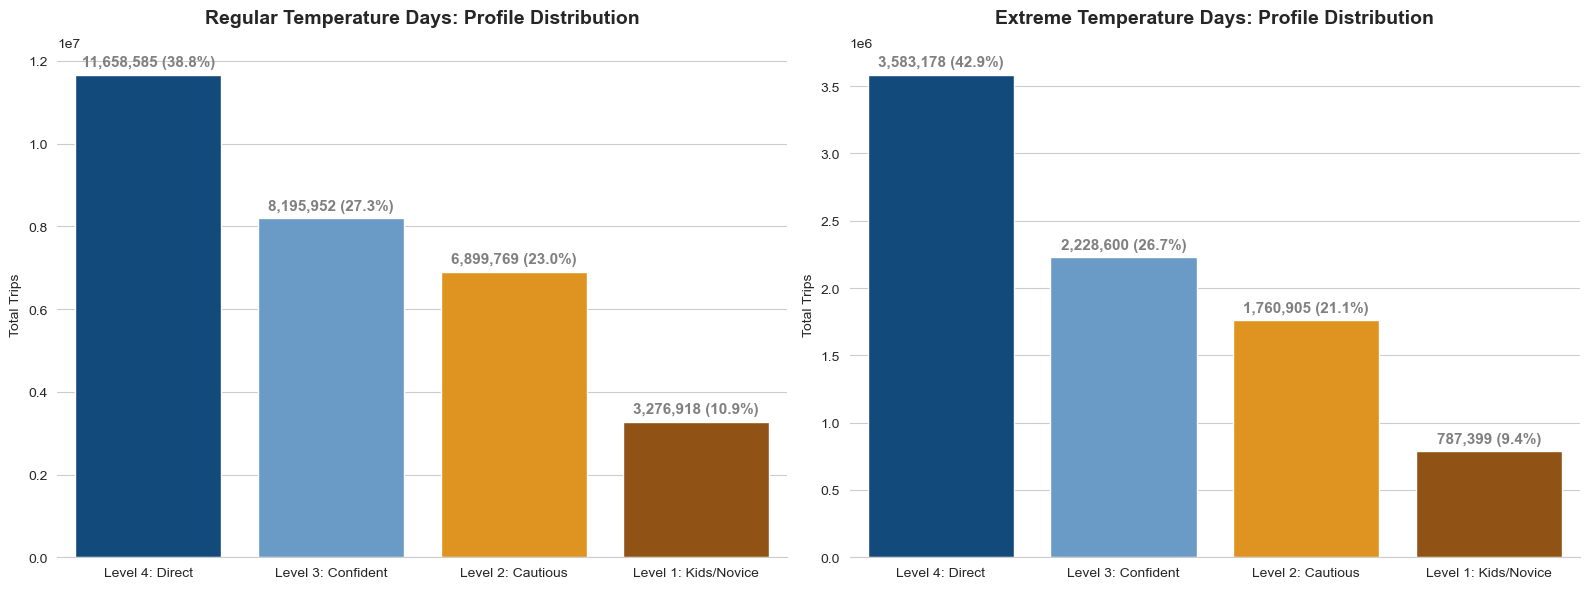

In [13]:
mask = (df_cleaned['temperature_c'] <= 5.0) | (df_cleaned['temperature_c'] >= 30.0)
df_normal = df_cleaned[~mask]
df_extreme = df_cleaned[mask]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_distribution(
    df_normal, 
    'estimated_profile', 
    axes[0], 
    "Regular Temperature Days: Profile Distribution", 
    labels_map=map_profiles, 
    palette=custom_palette
)

plot_distribution(
    df_extreme, 
    'estimated_profile', 
    axes[1], 
    "Extreme Temperature Days: Profile Distribution", 
    labels_map=map_profiles, 
    palette=custom_palette
)

plt.tight_layout()
plt.show()

Analogous to the observations during intense precipitation episodes, the aggregation of these extreme thermal conditions reveals an initial prioritization of temporal efficiency over safety, evidenced by an increase in the adoption of the direct profile from 38.8% to 42.9%. This pattern suggests a strategy aimed at minimizing exposure time to the elements. However, to accurately understand the isolated effect of each thermal variable, it is methodologically necessary to disaggregate the analysis and contrast the specific impact of low temperatures versus high temperatures.

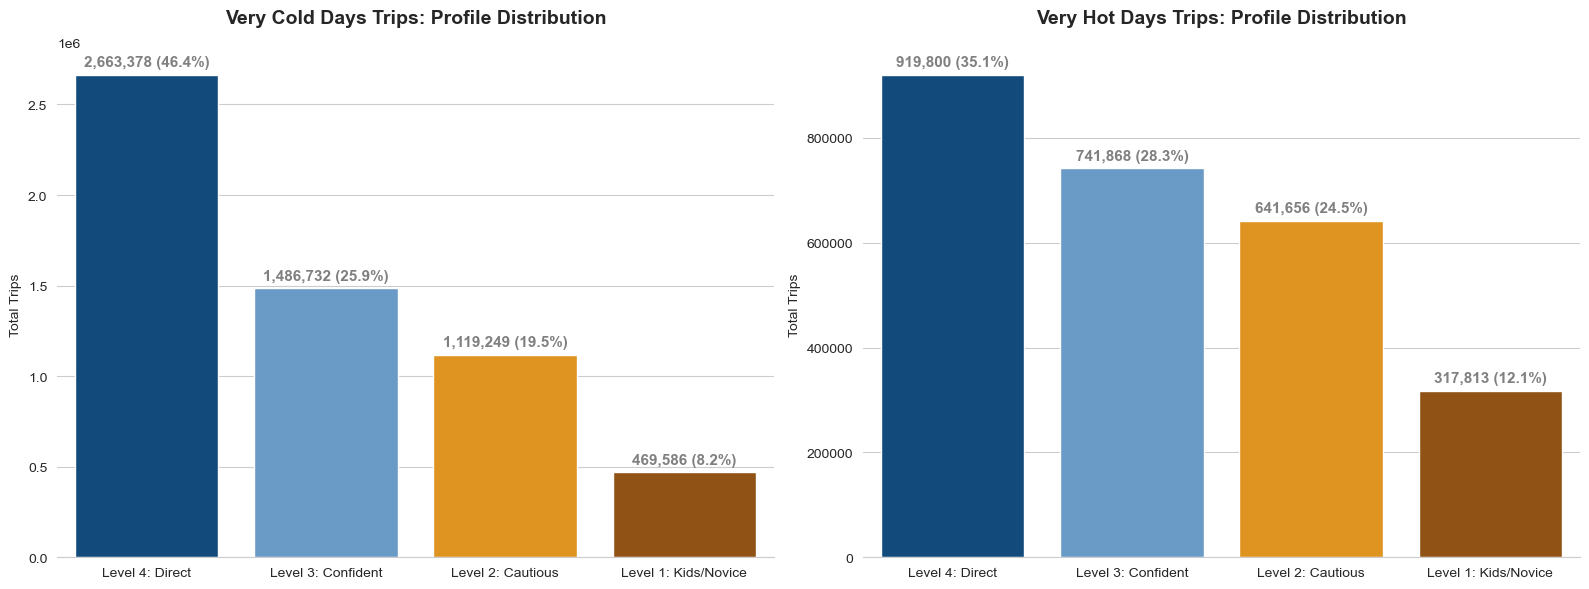

In [14]:
df_cold = df_cleaned[df_cleaned['temperature_c'] <= 5.0]
df_hot = df_cleaned[df_cleaned['temperature_c'] >= 30.0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_distribution(
    df_cold, 
    'estimated_profile', 
    axes[0], 
    "Very Cold Days Trips: Profile Distribution", 
    labels_map=map_profiles, 
    palette=custom_palette
)

plot_distribution(
    df_hot, 
    'estimated_profile', 
    axes[1], 
    "Very Hot Days Trips: Profile Distribution", 
    labels_map=map_profiles, 
    palette=custom_palette
)

plt.tight_layout()
plt.show()

Upon performing this disaggregation, highly notable behavioral differences emerge, reflecting a shift in user typology. During days of severe cold, the system is predominantly utilized by inelastic or captive demand (mandatory commuters) seeking to complete their journeys as quickly as possible to avoid thermal exposure. Conversely, intense heat episodes boost a significant rebound in occasional and recreational demand. This shift towards leisure oriented usage translates into a higher propensity to navigate low stress infrastructure, as evidenced by the increased use of the maximum safety profile (LTS1), rising from 8.2% to 12.1%, and the cautious profile (LTS2), rising from 19.5% to 24.5%.

## Route Comparison Across Profiles

As the final section of this notebook, a visual representation of the route differences based on the user profile will be presented. To achieve this, a chart comparing the four profiles for a single route will be displayed to visually highlight the differences and specific characteristics of each.

First, to free up memory space, the previously used dataframes will be deleted, as they contain information that is no longer useful for these types of visualizations.

In [3]:
import gc

try:
    del df_cleaned, df_original
    gc.collect()
    print("RAM cleaned successfully")
except:
    print("Dataframes already deleted")

RAM cleaned successfully


Once the memory has been cleared (a necessary step given the large file sizes involved), the map corresponding to the route between a pair of stations will be generated according to the selected profile. This will allow for a visual comparison of the differences between the route types.

In [10]:
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from shapely import wkt

def get_route_data(df, start_id, end_id, profile_name):
    mask = (df['start_station_id'] == start_id) & \
           (df['end_station_id'] == end_id) & \
           (df['profile'] == profile_name)
    
    if mask.sum() == 0:
        raise ValueError(f"The route for the profile {profile_name} was not found")
    
    row = df[mask].iloc[0]
    return wkt.loads(row['geometry']), row['time_min'], row['distance_m']

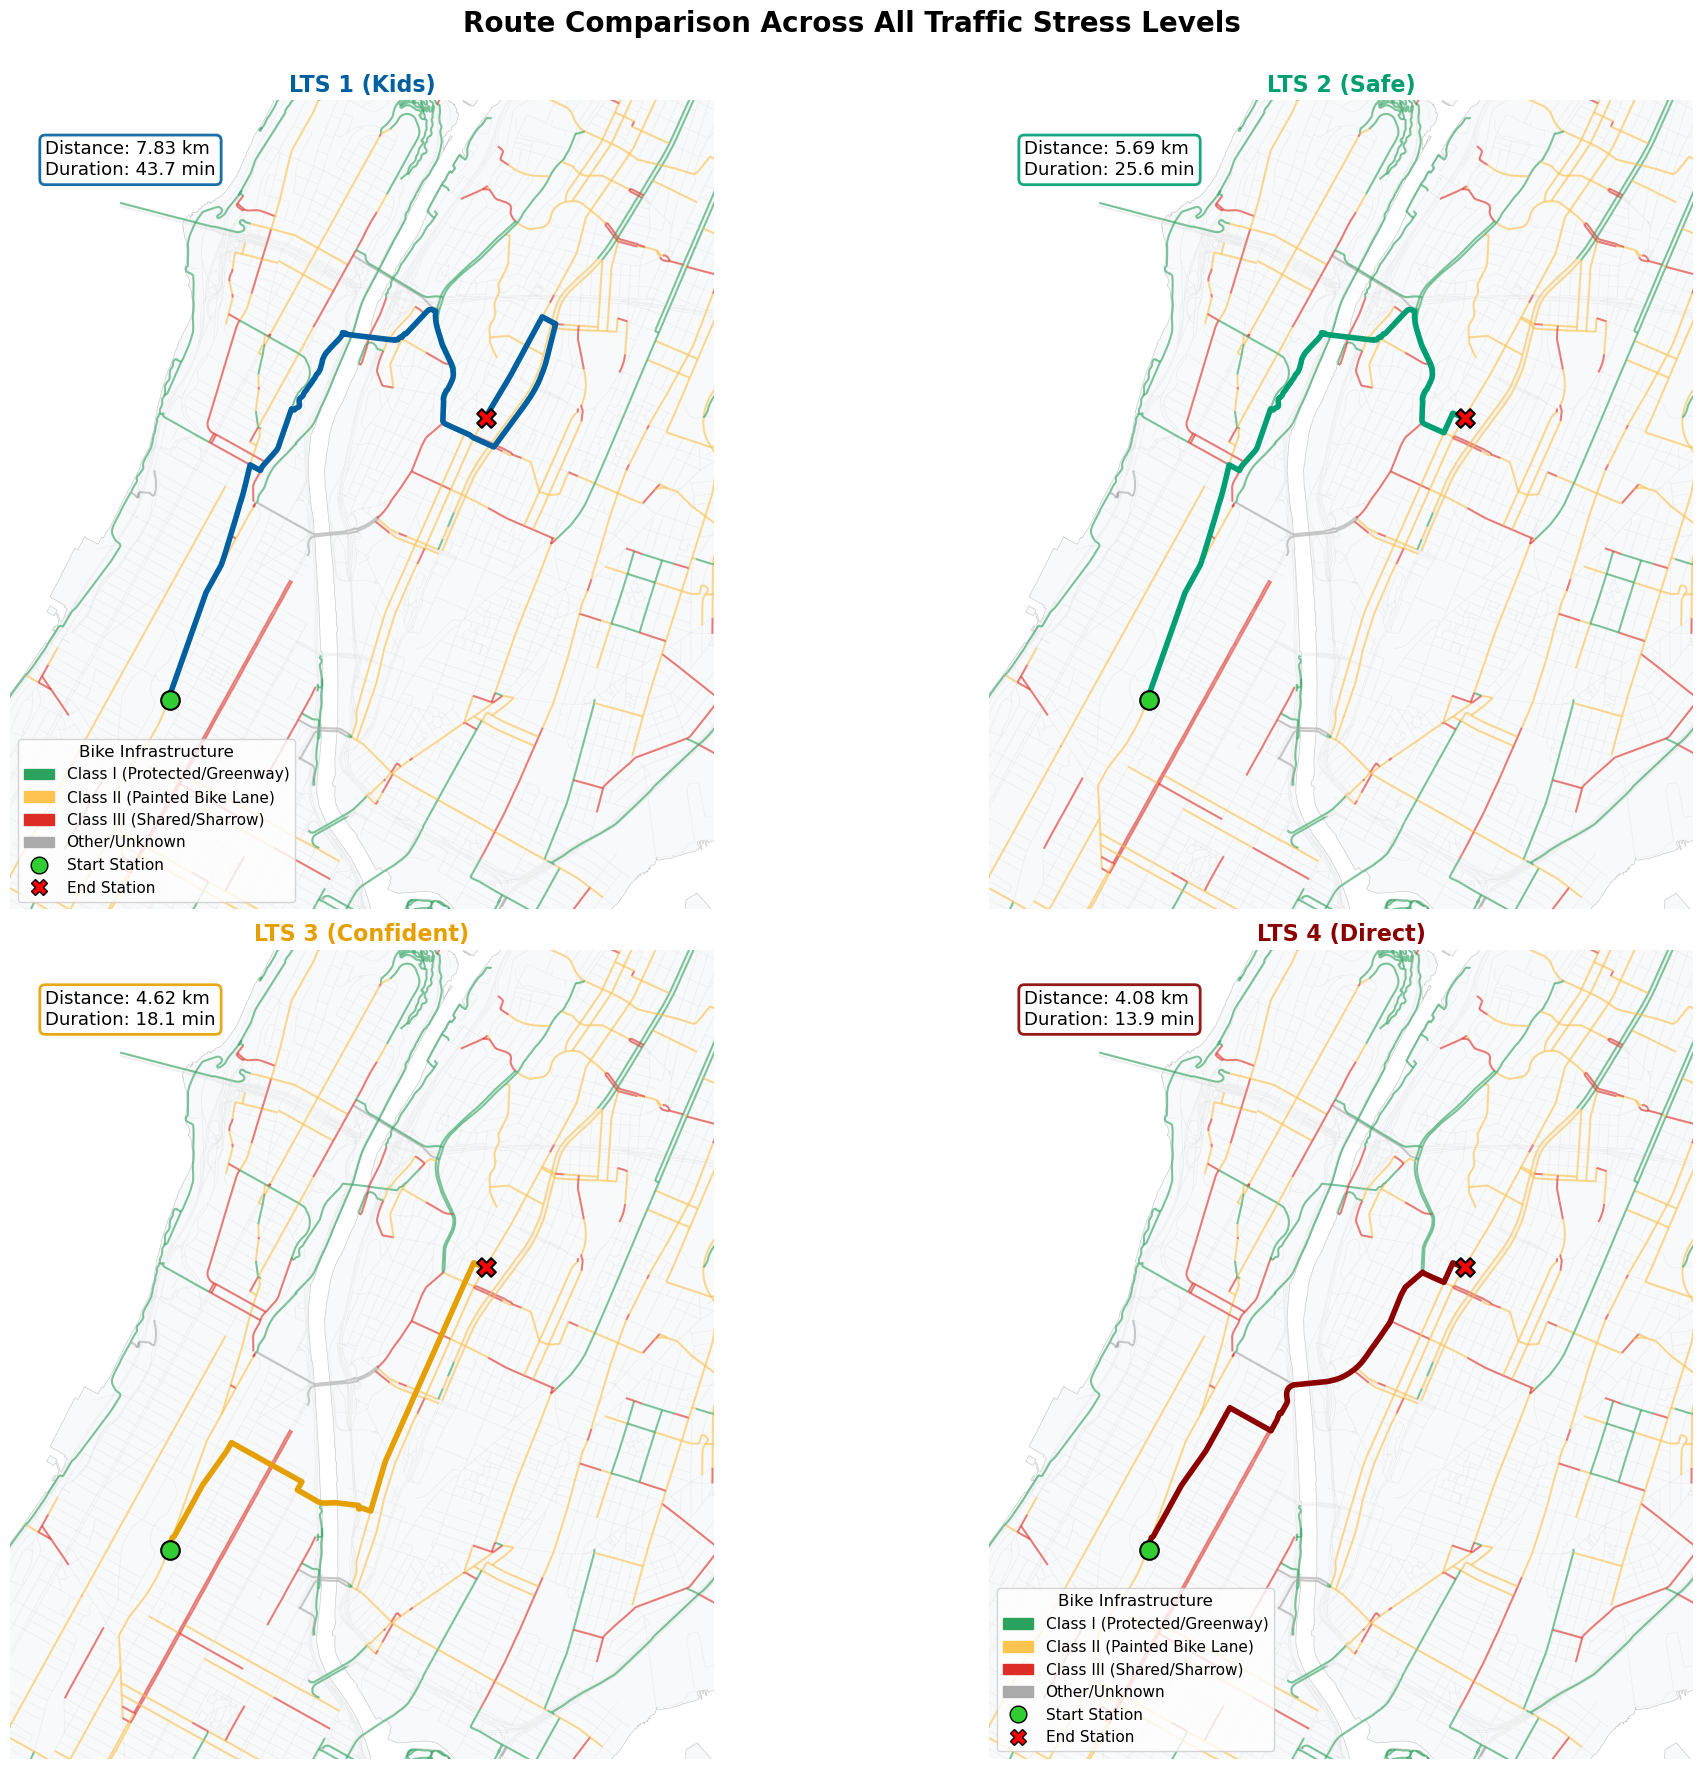

In [11]:
MATRIX_FILE = '../../data/processed/matrix_routes/batch_1.parquet'
df_matrix = pd.read_parquet(MATRIX_FILE)

ny_boroughs = gpd.read_file('../../data/raw/city/Borough_Boundaries_20260126.geojson')
ny_streets = gpd.read_file('../../data/raw/city/Centerline_20260126.geojson')
bike_infra = gpd.read_file('../../data/raw/infrastructure/New_York_City_Bike_Routes_20260123.geojson')

start_station = '7837.3'
end_station = '8179.03'

geom_lts1, dur_lts1, dist_lts1 = get_route_data(df_matrix, start_station, end_station, 'lts1_kids')
geom_lts2, dur_lts2, dist_lts2 = get_route_data(df_matrix, start_station, end_station, 'lts2_safe')
geom_lts3, dur_lts3, dist_lts3 = get_route_data(df_matrix, start_station, end_station, 'lts3_confident')
geom_lts4, dur_lts4, dist_lts4 = get_route_data(df_matrix, start_station, end_station, 'lts4_direct')

start_coords = geom_lts1.coords[0]
end_coords = geom_lts1.coords[-1]

routes_gdf = gpd.GeoDataFrame({
    'profile': ['LTS 1 (Kids)', 'LTS 2 (Safe)', 'LTS 3 (Confident)', 'LTS 4 (Direct)'],
    'duration': [dur_lts1, dur_lts2, dur_lts3, dur_lts4],
    'distance': [dist_lts1, dist_lts2, dist_lts3, dist_lts4],
    'color': ['#005f9e', '#009e73', '#e69f00', '#8b0000'],
    'geometry': [geom_lts1, geom_lts2, geom_lts3, geom_lts4]
}, crs="EPSG:4326")

color_dict = {
    'I': '#2ca25f',
    'II': '#fec44f',
    'III': '#de2d26'
}
bike_infra['color'] = bike_infra['facilitycl'].map(color_dict).fillna('#aaaaaa')
color_street = '#e0e0e0'

fig, axes = plt.subplots(2, 2, figsize=(22, 18), sharex=True, sharey=True)
fig.suptitle(f'Route Comparison Across All Traffic Stress Levels', fontsize=20, fontweight='bold')
axes = axes.flatten()

for i, ax in enumerate(axes):
    ny_boroughs.plot(ax=ax, color='#f8f9fa', edgecolor='#cccccc', linewidth=0.5)  
    ny_streets.plot(ax=ax, color=color_street, linewidth=0.5, alpha=0.5)
    bike_infra.plot(ax=ax, color=bike_infra['color'], linewidth=1.5, alpha=0.6)
    
    actual_profile = routes_gdf.iloc[[i]]
    route_color = actual_profile['color'].iloc[0]
    profile_name = actual_profile['profile'].iloc[0]
    
    actual_profile.plot(ax=ax, color=route_color, linewidth=4)
    ax.set_title(profile_name, fontsize=16, fontweight='bold', color=route_color)

    ax.scatter(start_coords[0], start_coords[1], color='#32CD32', s=180, marker='o', 
               edgecolor='black', linewidth=1.5, zorder=10)
    ax.scatter(end_coords[0], end_coords[1], color='#FF0000', s=180, marker='X', 
               edgecolor='black', linewidth=1.5, zorder=10)

    duration = actual_profile['duration'].iloc[0]
    distance_km = actual_profile['distance'].iloc[0] / 1000
    text_info = f"Distance: {distance_km:.2f} km\nDuration: {duration:.1f} min"

    ax.text(0.05, 0.95, text_info, transform=ax.transAxes, fontsize=13,
            verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor=route_color, linewidth=2))
        
    ax.axis('off')

legend_elements = [
    mpatches.Patch(color='#2ca25f', label='Class I (Protected/Greenway)'),
    mpatches.Patch(color='#fec44f', label='Class II (Painted Bike Lane)'),
    mpatches.Patch(color='#de2d26', label='Class III (Shared/Sharrow)'),
    mpatches.Patch(color='#aaaaaa', label='Other/Unknown'),
    mlines.Line2D([], [], color='#32CD32', marker='o', linestyle='None',
                          markersize=12, markeredgecolor='black', label='Start Station'),
    mlines.Line2D([], [], color='#FF0000', marker='X', linestyle='None',
                          markersize=12, markeredgecolor='black', label='End Station')
]
axes[0].legend(handles=legend_elements, loc='lower left', title="Bike Infrastructure", fontsize=11, title_fontsize=12)
axes[3].legend(handles=legend_elements, loc='lower left', title="Bike Infrastructure", fontsize=11, title_fontsize=12)

minx, miny, maxx, maxy = routes_gdf.total_bounds
margin = 0.015
axes[0].set_xlim(minx - margin, maxx + margin)
axes[0].set_ylim(miny - margin, maxy + margin)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

This example perfectly illustrates the differences between the four types of profiles.

On one hand, Profile 1, corresponding to the safest profile, covers the greatest distance. This occurs because, by definition, distance has minimal influence on this profile, whereas heavy penalties are applied for riding outside designated bike lanes. Consequently, to ride strictly to cycling infrastructure, it covers a longer distance than the other profiles. Furthermore, given that this represents a novice user, not only is the distance greater, but the assumed speed is lower, resulting in a route that takes between two and three times longer than the others.

Regarding Profile 2, a different type of user behavior is observed. This user prioritizes riding on bike lanes, showing a willingness to take a longer detour to remain on cycling infrastructure for as long as possible. The main difference from the first profile can be spotted near the end of the route. While the first profile takes a detour that adds 2 km to the journey, this cyclist places slightly more value on route distance. Therefore, they prefer to ride a final segment without a bike lane to save that extra distance.

Profile 3 represents an experienced user who prefers to use bike lanes but will readily take a shortcut if it saves distance, regardless of the available cycling infrastructure. Thus, it can be observed that at the beginning of the route, the bike lane is entirely ignored until the river is crossed, at which point the user rejoins the lane until reaching the destination. By doing so, they eliminate 1 km from the journey that would have been required under Profile 2's routing.

Finally, the most direct profile seeks only the shortest path. In this case, the presence or absence of a bike lane is irrelevant, the sole objective is the shortest route, regardless of the existing cycling infrastructure. Consequently, it is the shortest route of the four, covering only 4 km, unlike the first profile's route, which covers nearly double that distance.